# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [12]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


[standardize_dataset] Removed 1 omission trial(s) from 'Choice'.


In [13]:
# Load test data

no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,Group,Overtrain,RT,RuleChangeTrials,NewSessionTrials,StartDate
0,1,1,go right,left,left,no,notOT,no,0.8,0,0,06-Mar-2023
1,2,1,go right,right,right,yes,notOT,no,0.4,0,0,06-Mar-2023
2,3,1,go right,left,left,no,notOT,no,0.4,0,0,06-Mar-2023
3,4,1,go right,left,right,no,notOT,no,0.4,0,0,06-Mar-2023
4,5,1,go right,left,left,no,notOT,no,0.4,0,0,06-Mar-2023


In [14]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [15]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_84115/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [16]:
# Session-end lookup: for each trial, find the last trial index of its session
session_last = TestData.groupby("SessionIndex").apply(lambda g: g.index[-1], include_groups=False)
TestData["session_end_idx"] = TestData["SessionIndex"].map(session_last)
session_end_array = TestData["session_end_idx"].values

print("Session end indices:")
for sid in sorted(TestData["SessionIndex"].unique()):
    end_idx = int(TestData[TestData["SessionIndex"] == sid].index[-1])
    rule = TestData[TestData["SessionIndex"] == sid]["TargetRule"].iloc[0]
    print(f"  Session {sid}: ends at trial index {end_idx}  (rule: {rule})")

Session end indices:
  Session 1: ends at trial index 49  (rule: go right)
  Session 3: ends at trial index 268  (rule: go right)
  Session 6: ends at trial index 351  (rule: go left)
  Session 7: ends at trial index 499  (rule: go left)
  Session 9: ends at trial index 610  (rule: go right)
  Session 11: ends at trial index 722  (rule: go left)
  Session 13: ends at trial index 784  (rule: go right)
  Session 15: ends at trial index 912  (rule: go left)
  Session 17: ends at trial index 1064  (rule: go right)
  Session 19: ends at trial index 1236  (rule: go left)
  Session 21: ends at trial index 1304  (rule: go right)
  Session 23: ends at trial index 1406  (rule: go left)


In [17]:
def detect_learning_per_block_targeted(Output_collection,
                                       block_starts,
                                       block_ends,
                                       block_target_strategies,
                                       session_end_array,
                                       chance_level=0.5,
                                       min_trials=5):
    """
    For each block, detect learning using the correct strategy for that block.
    Learning criterion: MAP stays above chance_level from trial t until the END OF THE SESSION
    (last trial of the same SessionIndex as trial t — not the block end).
    """
    learning_trials = []

    for start, end, target_strategy in zip(block_starts, block_ends, block_target_strategies):

        MAP = Output_collection[target_strategy]["MAPprobability"].values

        lt = None
        for t in range(start, end):
            sess_end = int(session_end_array[t]) + 1
            remaining = MAP[t:sess_end]
            if len(remaining) >= min_trials and np.all(remaining > chance_level):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

if "RuleChangeTrials" in TestData.columns:
    block_boundaries = list(TestData.index[TestData["RuleChangeTrials"] == 1])
else:
    block_boundaries = []

block_starts = [0] + block_boundaries
block_ends   = block_boundaries + [len(TestData)]

if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    block_labels = ["go right", "go to the lit arm", "go left", "go to the dark arm"][:len(block_starts)]



In [18]:
# -------------------------------------------------
# Map each task rule to the corresponding strategy
# -------------------------------------------------

rule_to_strategy = {
    "go right": "go_right",
    "Right Arm": "go_right",
    "go to the lit arm": "go_cued",
    "Lit Arm": "go_cued",
    "go left": "go_left",
    "Left Arm": "go_left",
    "go to the dark arm": "go_uncued",
    "Unlit Arm": "go_uncued"
}

block_target_strategies = [rule_to_strategy[label] for label in block_labels]
print("Block labels:", block_labels)
print("Strategy mapping:", block_target_strategies)

Block labels: ['go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right', 'go left', 'go right']
Strategy mapping: ['go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right', 'go_left', 'go_right']


## Learning Detection — Sequence Criterion

**Definition (paper, Strategy 1):**  
Learning is detected at the first trial *t* where the MAP probability of the target strategy exceeds chance (0.5) and **remains above chance for every subsequent trial until the end of the session in which trial *t* occurs**.

This is the "sequence criterion": not just a momentary rise above chance, but a sustained stay above chance through the end of that recording session.

- `session_end_array[t]` gives the last trial index of the session containing trial *t*
- `MAP[t : session_end + 1]` is the window checked
- `min_trials = 5` guards against spurious detections at the very end of a session

In [19]:
chance_level = 0.5

learning_trials_blocks = detect_learning_per_block_targeted(
    Output_collection=Output_collection,
    block_starts=block_starts,
    block_ends=block_ends,
    block_target_strategies=block_target_strategies,
    session_end_array=session_end_array,
    chance_level=chance_level
)

print("Learning trials per block:", learning_trials_blocks)

Learning trials per block: [8, 188, 492, 580, 650, 777, 818, 1002, 1137, 1288, 1362]


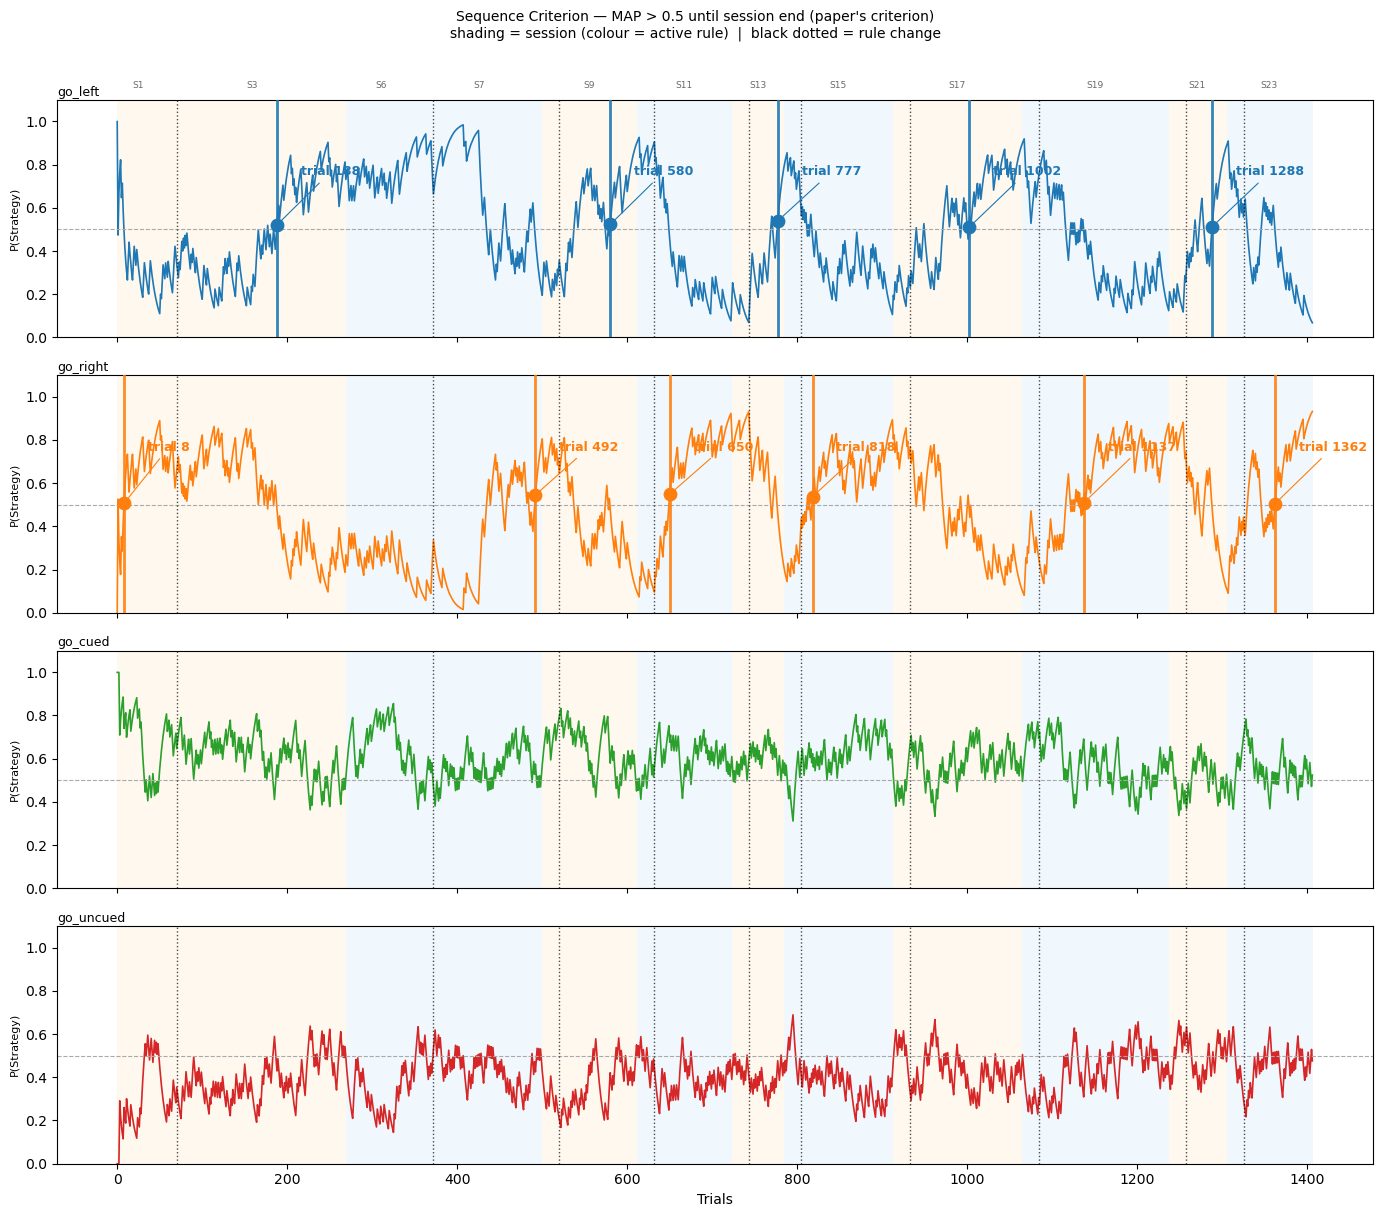


Learning trials per block:
  go right (go_right): trial 8
  go left (go_left): trial 188
  go right (go_right): trial 492
  go left (go_left): trial 580
  go right (go_right): trial 650
  go left (go_left): trial 777
  go right (go_right): trial 818
  go left (go_left): trial 1002
  go right (go_right): trial 1137
  go left (go_left): trial 1288
  go right (go_right): trial 1362


In [20]:
color_map = {
    "go_left":   "#1f77b4",
    "go_right":  "#ff7f0e",
    "go_cued":   "#2ca02c",
    "go_uncued": "#d62728",
}

# Background color per rule
rule_bg = {
    "go right":           "#fff3e0",  # light orange
    "go left":            "#e3f2fd",  # light blue
    "go to the lit arm":  "#e8f5e9",  # light green
    "go to the dark arm": "#fce4ec",  # light pink
}

# Build session spans: (start_idx, end_idx, session_id, rule)
session_spans = []
for sid in sorted(TestData["SessionIndex"].unique()):
    s = TestData[TestData["SessionIndex"] == sid]
    session_spans.append((s.index[0], s.index[-1], int(sid), s["TargetRule"].iloc[0]))

plot_strategies = [s for s in strategies if not s.startswith("win_stay") and not s.startswith("lose_shift")]

n = len(plot_strategies)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)

for i, (ax, strategy) in enumerate(zip(axes, plot_strategies)):
    MAP = Output_collection[strategy]["MAPprobability"]
    color = color_map.get(strategy, "steelblue")

    # Shaded session backgrounds + session number labels (top subplot only)
    for start_idx, end_idx, sid, rule in session_spans:
        bg = rule_bg.get(rule, "#f5f5f5")
        ax.axvspan(start_idx, end_idx + 1, facecolor=bg, alpha=0.5, zorder=0)
        if i == 0:
            mid = (start_idx + end_idx) / 2
            ax.text(mid, 1.04, f"S{sid}", fontsize=6.5, color="dimgrey",
                    ha="center", va="bottom", transform=ax.get_xaxis_transform())

    ax.plot(MAP, linewidth=1.2, color=color, zorder=2)
    ax.axhline(y=0.5, color="darkgrey", linestyle="--", linewidth=0.8, zorder=2)

    # Rule change boundaries
    for b in [s[0] for s in session_spans[1:] if s[3] != session_spans[session_spans.index(s)-1][3]
              ] if False else []:  # placeholder — use block_boundaries instead
        pass
    for b in block_boundaries:
        ax.axvline(b, color="black", linestyle=":", linewidth=1.0, alpha=0.7, zorder=3)

    # Per-block learning markers
    for lt, block_strat in zip(learning_trials_blocks, block_target_strategies):
        if block_strat == strategy and lt is not None:
            ax.axvline(lt, linewidth=2, color=color, alpha=0.9, zorder=4)
            ax.scatter(lt, MAP.values[lt], s=80, color=color, zorder=5)
            ax.annotate(
                f"trial {lt}",
                xy=(lt, MAP.values[lt]),
                xytext=(lt + no_Trials * 0.02, 0.75),
                fontsize=9, color=color, fontweight="bold",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8)
            )

    ax.set_ylabel("P(Strategy)", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(strategy, fontsize=9, loc="left", pad=3)

axes[-1].set_xlabel("Trials")
fig.suptitle("Sequence Criterion — MAP > 0.5 until session end (paper's criterion)\n"
             "shading = session (colour = active rule)  |  black dotted = rule change",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

print("\nLearning trials per block:")
for label, strat, lt in zip(block_labels, block_target_strategies, learning_trials_blocks):
    result = f"trial {lt}" if lt is not None else "not detected"
    print(f"  {label} ({strat}): {result}")

# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb